<a href="https://colab.research.google.com/github/vaishnavipokhriyal083-sudo/Wind_Energy_Efficiency_Project/blob/main/Wind_Energy_Efficency_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement -**

A wind farm operator wants to monitor and predict the efficiency of wind turbines using sensor data collected from turbines

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv('/content/train.csv')

In [3]:
df

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,2021-04-25 19:12:00,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,Turbine_13,50.768675
909600,2021-02-20 17:37:00,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,Turbine_158,44.234821
909601,2021-10-22 14:18:00,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,Turbine_15,46.942486
909602,2021-02-08 22:03:00,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,Turbine_97,46.392221


In [4]:
# check the top 5 rows of dataset
# check the bottom 5 rows of dataset
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [5]:
df.tail()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
909599,2021-04-25 19:12:00,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,Turbine_13,50.768675
909600,2021-02-20 17:37:00,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,Turbine_158,44.234821
909601,2021-10-22 14:18:00,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,Turbine_15,46.942486
909602,2021-02-08 22:03:00,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,Turbine_97,46.392221
909603,2021-04-09 14:28:00,4.843147,10.779734,19.452520,736.601664,60.603885,78.559767,30.798932,38.252200,2.763231,1.320198,11.127739,2.017444,0.963029,Turbine_105,48.902180


In [6]:
# check the information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   active_power_calculated_by_converter    909604 non-null  float64
 2   active_power_raw                        909604 non-null  float64
 3   ambient_temperature                     909604 non-null  float64
 4   generator_speed                         909604 non-null  float64
 5   generator_winding_temp_max              909604 non-null  float64
 6   grid_power10min_average                 909604 non-null  float64
 7   nc1_inside_temp                         909604 non-null  float64
 8   nacelle_temp                            909604 non-null  float64
 9   reactice_power_calculated_by_converter  909604 non-null  float64
 10  reactive_power                          9096

In [7]:
# check for null values
# check for duplicate values
df.isnull()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
909600,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
909601,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
909602,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

,0
timestamp,0
active_power_calculated_by_converter,0
active_power_raw,0
ambient_temperature,0
generator_speed,0
generator_winding_temp_max,0
grid_power10min_average,0
nc1_inside_temp,0
nacelle_temp,0
reactice_power_calculated_by_converter,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
print(df.isnull().sum().sum())

0


In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
909599,False
909600,False
909601,False
909602,False


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
print(df.duplicated().sum())

0


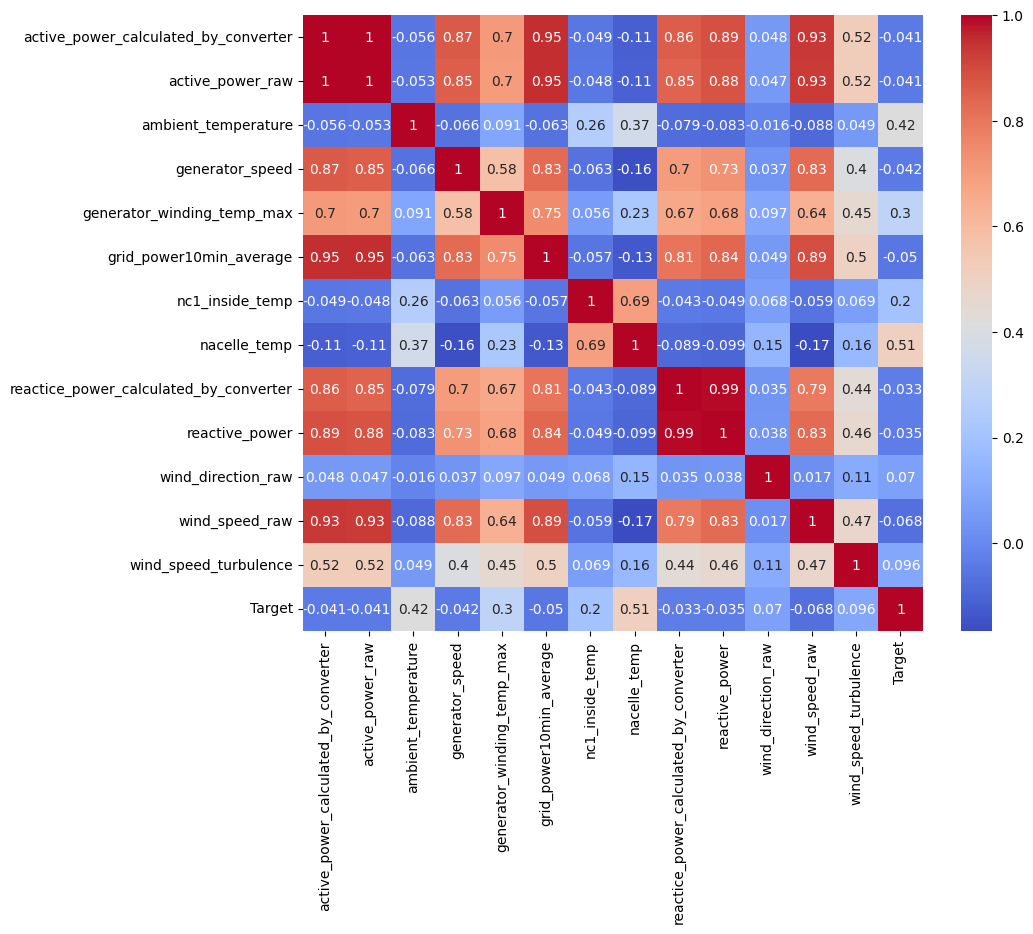

In [19]:
# create a heatmap to check the multicollinearity
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)

In [24]:
col_list

['active_power_calculated_by_converter',
 'active_power_raw',
 'ambient_temperature',
 'generator_speed',
 'generator_winding_temp_max',
 'grid_power10min_average',
 'nc1_inside_temp',
 'nacelle_temp',
 'reactice_power_calculated_by_converter',
 'reactive_power',
 'wind_direction_raw',
 'wind_speed_raw',
 'wind_speed_turbulence']

In [25]:
x = df[col_list]
x

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068
...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335


In [28]:
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0     active_power_calculated_by_converter  398.566300
1                         active_power_raw  361.707774
2                      ambient_temperature   13.134672
3                          generator_speed   75.538793
4               generator_winding_temp_max  127.768808
5                  grid_power10min_average   30.870003
6                          nc1_inside_temp  140.004469
7                             nacelle_temp  255.939425
8   reactice_power_calculated_by_converter  328.529943
9                           reactive_power  427.087748
10                      wind_direction_raw    4.824868
11                          wind_speed_raw   74.328616
12                   wind_speed_turbulence    7.825816


In [29]:
df = df.drop(['reactive_power'],axis=1)

In [30]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0     active_power_calculated_by_converter  395.268258
1                         active_power_raw  350.365548
2                      ambient_temperature   13.104176
3                          generator_speed   74.194993
4               generator_winding_temp_max  127.029415
5                  grid_power10min_average   30.867511
6                          nc1_inside_temp  140.004381
7                             nacelle_temp  255.874458
8   reactice_power_calculated_by_converter   13.312498
9                       wind_direction_raw    4.821565
10                          wind_speed_raw   69.736803
11                   wind_speed_turbulence    7.825603


In [31]:
df = df.drop(['active_power_calculated_by_converter'],axis=1)

In [32]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0                         active_power_raw   40.939031
1                      ambient_temperature   13.102296
2                          generator_speed   70.251025
3               generator_winding_temp_max  126.042200
4                  grid_power10min_average   30.190083
5                          nc1_inside_temp  139.485541
6                             nacelle_temp  255.542439
7   reactice_power_calculated_by_converter   11.432388
8                       wind_direction_raw    4.821516
9                           wind_speed_raw   69.700467
10                   wind_speed_turbulence    7.822965


In [33]:
df = df.drop(['nacelle_temp'],axis=1)

In [34]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  40.386321
1                     ambient_temperature  12.644618
2                         generator_speed  70.085140
3              generator_winding_temp_max  76.623885
4                 grid_power10min_average  26.481121
5                         nc1_inside_temp  56.975296
6  reactice_power_calculated_by_converter  11.338216
7                      wind_direction_raw   4.750110
8                          wind_speed_raw  69.060440
9                   wind_speed_turbulence   7.477829


In [35]:
df = df.drop(['generator_winding_temp_max'],axis=1)

In [36]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  36.548322
1                     ambient_temperature  11.935077
2                         generator_speed  64.481775
3                 grid_power10min_average  23.620350
4                         nc1_inside_temp  46.515458
5  reactice_power_calculated_by_converter  10.627115
6                      wind_direction_raw   4.666287
7                          wind_speed_raw  67.601772
8                   wind_speed_turbulence   7.300019


In [37]:
df = df.drop(['wind_speed_raw'],axis=1)

In [38]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  31.140023
1                     ambient_temperature  11.913998
2                         generator_speed  49.190837
3                 grid_power10min_average  23.587148
4                         nc1_inside_temp  42.458906
5  reactice_power_calculated_by_converter  10.575211
6                      wind_direction_raw   4.661972
7                   wind_speed_turbulence   7.292047


In [39]:
df = df.drop(['generator_speed'],axis=1)

In [44]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                     ambient_temperature  11.825219
1                 grid_power10min_average   6.984664
2                         nc1_inside_temp  18.679671
3  reactice_power_calculated_by_converter   8.686431
4                      wind_direction_raw   4.612084
5                   wind_speed_turbulence   7.127731


In [45]:
df = df.drop(['active_power_raw'],axis=1)

KeyError: "['active_power_raw'] not found in axis"

In [46]:
col_list = []
for i in df.columns:
  if (df[i].dtypes =='float64' and i!='Target'):
    col_list.append(i)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                     ambient_temperature  11.825219
1                 grid_power10min_average   6.984664
2                         nc1_inside_temp  18.679671
3  reactice_power_calculated_by_converter   8.686431
4                      wind_direction_raw   4.612084
5                   wind_speed_turbulence   7.127731


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 9 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   ambient_temperature                     909604 non-null  float64
 2   grid_power10min_average                 909604 non-null  float64
 3   nc1_inside_temp                         909604 non-null  float64
 4   reactice_power_calculated_by_converter  909604 non-null  float64
 5   wind_direction_raw                      909604 non-null  float64
 6   wind_speed_turbulence                   909604 non-null  float64
 7   turbine_id                              909604 non-null  object 
 8   Target                                  909604 non-null  float64
dtypes: float64(7), object(2)
memory usage: 62.5+ MB


In [48]:
df['timestamp']

,timestamp
0,2021-02-19 20:18:00
1,2021-04-27 04:55:00
2,2021-01-25 06:26:00
3,2021-10-30 03:47:00
4,2021-03-15 00:39:00
...,...
909599,2021-04-25 19:12:00
909600,2021-02-20 17:37:00
909601,2021-10-22 14:18:00
909602,2021-02-08 22:03:00


In [49]:
# convert timestamp to datetime datatype
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 9 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   ambient_temperature                     909604 non-null  float64       
 2   grid_power10min_average                 909604 non-null  float64       
 3   nc1_inside_temp                         909604 non-null  float64       
 4   reactice_power_calculated_by_converter  909604 non-null  float64       
 5   wind_direction_raw                      909604 non-null  float64       
 6   wind_speed_turbulence                   909604 non-null  float64       
 7   turbine_id                              909604 non-null  object        
 8   Target                                  909604 non-null  float64       
dtypes: datetime64[ns](1), float64(7), obje

In [51]:
df['timestamp']

,timestamp
0,2021-02-19 20:18:00
1,2021-04-27 04:55:00
2,2021-01-25 06:26:00
3,2021-10-30 03:47:00
4,2021-03-15 00:39:00
...,...
909599,2021-04-25 19:12:00
909600,2021-02-20 17:37:00
909601,2021-10-22 14:18:00
909602,2021-02-08 22:03:00


In [52]:
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

In [ ]:
df['hour']

,hour
0,20
1,4
2,6
3,3
4,0
...,...
909599,19
909600,17
909601,14
909602,22


In [53]:
df['month']

,month
0,2
1,4
2,1
3,10
4,3
...,...
909599,4
909600,2
909601,10
909602,2


In [55]:
df['month'].unique()

array([ 2,  4,  1, 10,  3,  5,  8,  7,  6,  9, 11, 12], dtype=int32)

In [56]:
#perforn encoding
from sklearn.preprocessing import LabelEncoder
le =  LabelEncoder()


In [57]:
df['turbine_id'] = le.fit_transform(df['turbine_id'])

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 11 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   ambient_temperature                     909604 non-null  float64       
 2   grid_power10min_average                 909604 non-null  float64       
 3   nc1_inside_temp                         909604 non-null  float64       
 4   reactice_power_calculated_by_converter  909604 non-null  float64       
 5   wind_direction_raw                      909604 non-null  float64       
 6   wind_speed_turbulence                   909604 non-null  float64       
 7   turbine_id                              909604 non-null  int64         
 8   Target                                  909604 non-null  float64       
 9   hour                                 

**Model Building**

In [ ]:
#Build Linear Regression model and check the accuracy.
#Build Decision Tree model and check the accuracy.
#Build Random Forest model and check the accuracy.

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
x= df.drop(['Target','timestamp'],axis = 1)
y= df['Target']

In [63]:
x

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
0,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,4,20,2
1,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,12,4,4
2,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,3,6,1
3,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,10,3,10
4,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,0,0,3
...,...,...,...,...,...,...,...,...,...
909599,32.736076,1343.320577,32.291391,152.216446,189.901812,1.028960,7,19,4
909600,30.540500,177.620552,30.434302,85.353107,93.417590,0.595874,11,17,2
909601,30.901129,873.414622,30.491818,42.820210,230.988398,0.951241,10,14,10
909602,32.697933,95.865704,32.338824,86.549094,65.408801,0.247335,15,22,2


In [62]:
y

,Target
0,47.582787
1,46.070328
2,39.989236
3,46.056587
4,54.346095
...,...
909599,50.768675
909600,44.234821
909601,46.942486
909602,46.392221


In [64]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.3 , random_state = 42)

In [65]:
x_test

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
426694,15.459007,1471.748393,28.793362,313.661758,301.904429,1.045399,12,19,5
905999,27.845619,1008.920614,37.662596,139.797746,186.715508,0.817224,9,23,6
771887,23.095029,106.174741,19.514506,94.990458,23.967815,0.259156,3,22,1
46228,15.379940,6.970462,30.462220,0.001689,35.344137,0.525956,6,11,11
415224,34.233847,86.192243,30.285461,109.491933,13.714096,0.523744,0,10,4
...,...,...,...,...,...,...,...,...,...
651822,35.203617,227.067998,34.812632,85.717745,251.038526,0.523350,15,16,10
854085,33.266666,172.138372,32.896361,110.340757,12.426453,0.447644,0,17,2
286421,16.957493,274.770650,33.771198,88.132955,284.573608,0.321291,6,22,3
149029,15.004905,212.265147,29.661602,88.757366,54.897278,0.284609,6,1,11


In [66]:
x_train

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
558113,25.453930,155.924385,38.866439,81.063222,325.621836,0.352868,9,16,12
528631,12.444449,518.075598,33.985083,99.965415,293.095500,0.445195,2,23,9
901818,34.754176,40.792043,31.009566,73.470582,282.419622,0.712787,7,13,3
51713,15.013254,1000.009495,29.923834,164.091302,51.174199,2.072739,6,14,5
468467,16.307150,358.151530,32.537337,94.987119,285.854223,0.817187,6,12,1
...,...,...,...,...,...,...,...,...,...
259178,24.756806,290.162450,33.974876,85.577305,90.830528,0.664922,2,16,1
365838,13.528913,286.760544,28.294377,86.778469,260.453438,0.653391,7,9,9
131932,14.465094,848.295858,32.133495,150.095634,298.630366,0.572769,13,22,1
671155,16.763954,666.027018,33.322253,135.396468,213.040166,0.788061,6,7,8


In [67]:
y_train

,Target
558113,46.631734
528631,45.118205
901818,49.018997
51713,47.209436
468467,41.911379
...,...
259178,43.719706
365838,46.517517
131932,43.004395
671155,43.907658


In [69]:
y_test

,Target
426694,48.591511
905999,48.263920
771887,43.726114
46228,43.581381
415224,52.543697
...,...
651822,46.780514
854085,50.099350
286421,45.009113
149029,45.122433


In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
model = LinearRegression()

In [72]:
model.fit(x_train,y_train)

LinearRegression()

In [73]:
y_pred = model.predict(x_test)

In [74]:
y_pred

array([44.9796377 , 47.38418069, 45.77310957, ..., 46.14366414,
       44.12951723, 46.1635491 ])

In [76]:
from sklearn.metrics import *

In [77]:
r2_score = r2_score(y_test , y_pred)

In [78]:
r2_score

0.238578226236408

In [79]:
r2_score*100

23.8578226236408

In [81]:
from sklearn.tree import DecisionTreeRegressor

In [82]:
model1 = DecisionTreeRegressor(random_state=73)

In [83]:
model1.fit(x_train , y_train)

DecisionTreeRegressor(random_state=73)

In [84]:
y_pred = model1.predict(x_test)

In [85]:
y_pred

array([48.30600866, 48.06216049, 43.70986938, ..., 45.03271866,
       45.12166391, 48.74316406])

In [86]:
from sklearn.metrics import *

In [87]:
score1 = r2_score(y_test , y_pred)

In [88]:
score1

0.8717967206990292

In [89]:
score1*100

87.17967206990292

In [90]:
from random import Random

In [91]:
from sklearn.ensemble import RandomForestRegressor

In [92]:
model2 = RandomForestRegressor(n_estimators = 100)

In [93]:
model2.fit(x_train , y_train)

RandomForestRegressor()

In [94]:
y_pred = model2.predict(x_test)

In [95]:
y_pred

array([48.27099062, 48.74503114, 43.79540586, ..., 45.38836431,
       45.14957009, 48.55690639])

In [96]:
from sklearn.metrics import*

In [97]:
acc = r2_score(y_test ,y_pred)

In [98]:
acc

0.9368752422811245

In [99]:
acc * 100

93.68752422811245

In [100]:
absolute_error =mean_absolute_error(y_test ,y_pred)

In [101]:
absolute_error

0.3996681261600896

In [123]:
from sklearn.metrics import mean_squared_error, r2_score

In [130]:
y_pred= RandomForestRegressor(n_estimators =100, random_state=42, n_jobs=-1)

In [131]:
y_pred = model2.predict(x_test)

In [132]:
r2 = r2_score (y_test , y_pred)

In [134]:
mae= mean_absolute_error(y_test,y_pred)

In [135]:
mae

0.4269572066113619

In [133]:
rmse = np.sqrt(mean_squared_error(y_test , y_pred)) #root mean squared error

In [117]:
rmse

np.float64(0.6996024910453675)

In [121]:
print(rmse)

0.6996024910453675


In [139]:
print(f"R2 Score(Variance Explained):{r2 * 100: .2f}%")
print(f"Mean Absolute Error (MAE): {mae: .4F}")
print(f"Root Mean Squared error (RMSE) {rmse: .4f}")

R2 Score(Variance Explained): 92.83%
Mean Absolute Error (MAE):  0.4270
Root Mean Squared error (RMSE)  0.6996


**Actual vs Predicted Values**

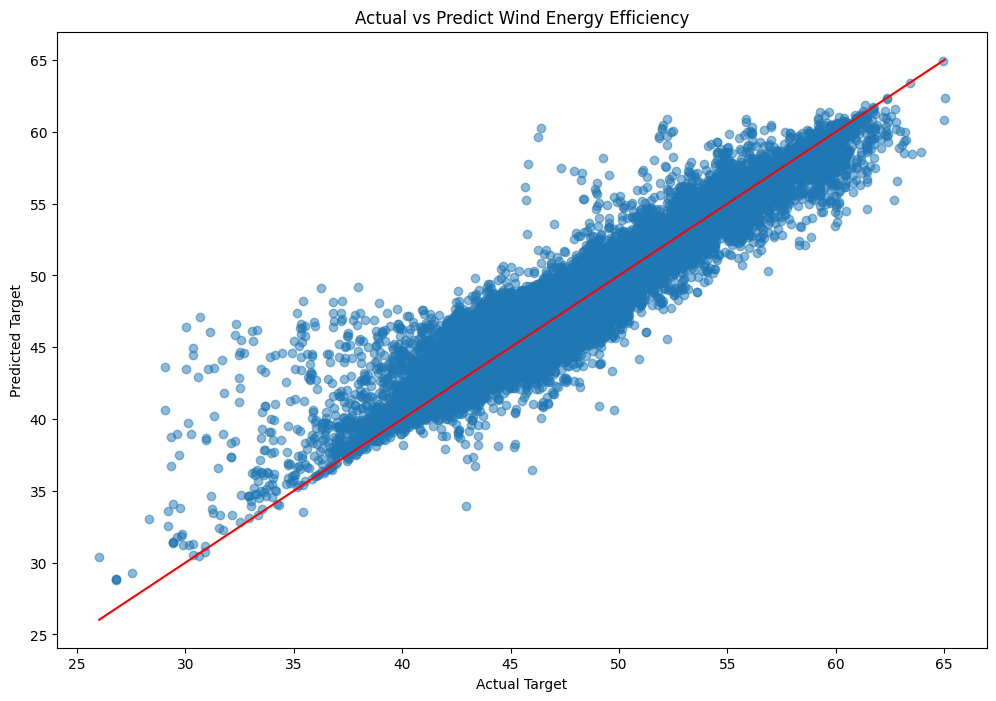

In [150]:
plt.figure(figsize=(12,8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(),y_test.max()],
         color='red')
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predict Wind Energy Efficiency")
plt.show()

**Feature Importance(Random Forest)**

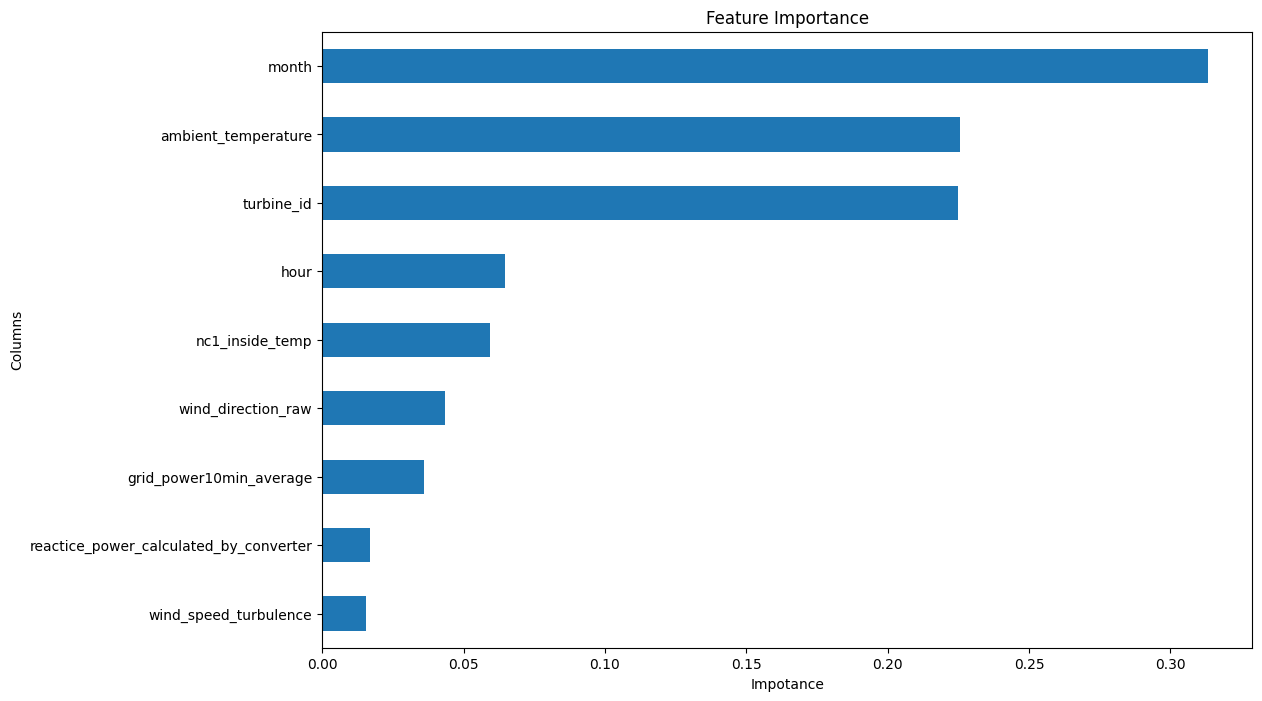

In [152]:
importance =model2.feature_importances_

feature_importance =pd.Series(importance, index=x_train.columns).sort_values()
feature_importance.plot(kind='barh',figsize=(12,8))
plt.title("Feature Importance")
plt.xlabel("Impotance")
plt.ylabel("Columns")
plt.show()


**Residual Plot**

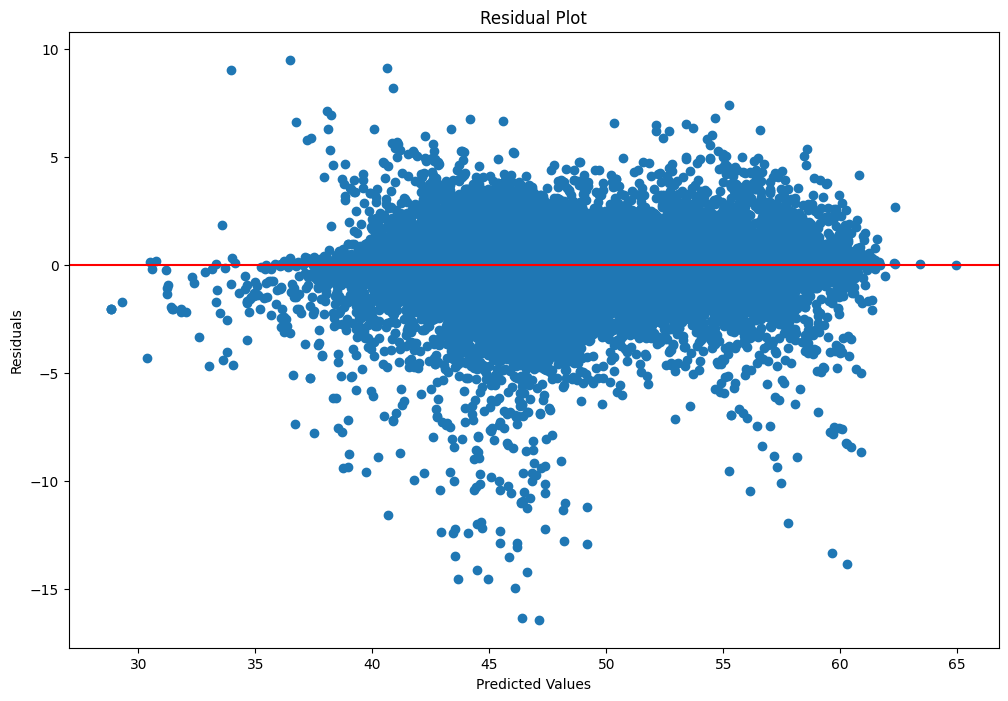

In [155]:
residuals = y_test - y_pred
plt.figure(figsize=(12,8))
plt.scatter(y_pred , residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Model Comparision Graph**

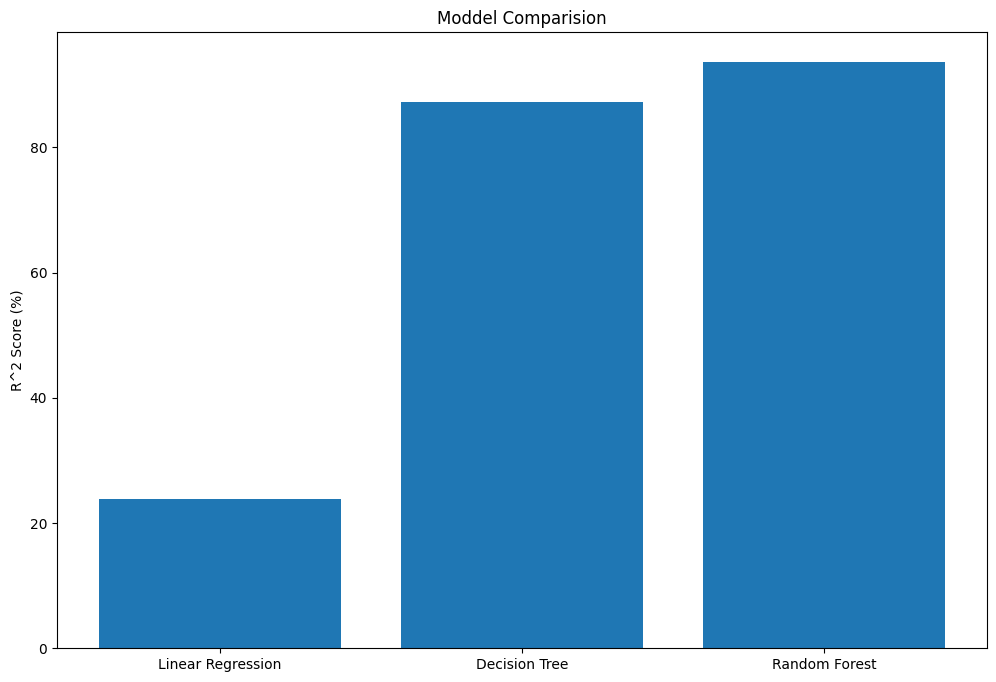

In [161]:
models=["Linear Regression",
       "Decision Tree",
       "Random Forest"]
scores =[23.85,87.18,93.68]

plt.figure(figsize=(12,8))
plt.bar(models,scores)
plt.ylabel("R^2 Score (%)")
plt.title("Moddel Comparision")
plt.show()

**1. Model Performance Summary
Create a summary table comparing all models.**

In [163]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R² Score": [23.86, 87.18, 93.68],
    "MAE": ["-", "-", 0.3997],
      "RMSE": ["-", "-", 0.6996]})
results

,Model,R² Score,MAE,RMSE
0,Linear Regression,23.86,-,-
1,Decision Tree,87.18,-,-
2,Random Forest,93.68,0.3997,0.6996


**2. Best Model Selection**
-
Among all the machine learning algorithms tested:
--
*   Linear Regression achieved an R² Score of -**23.86%**
*   Decision Tree achieved an R² Score of -**87.18%**
*   Random Forest achieved an R² Score of -**93.68%**

Random Forest Regressor performed the best because it captured the complex relationships between the wind parameters and wind energy efficiency more effectively than the other models

**3. Feature Importance Analysis**
--
*Feature Importance*

The Random Forest model identifies the most influential features affecting wind energy efficiency.

From the graph:

1. Month contributes significantly.
2. Ambient Temperature is highly important.
3. Turbine ID influences performance.
4. Hour has moderate importance.
5. Wind Direction contributes moderately.
6. Reactive Power has the least influence.

This analysis helps understand which factors most strongly affect wind energy production.

**4. Actual vs Predicted Interpretation**

*Actual vs Predicted Analysis*

The scatter plot compares the actual wind efficiency values with the model's predicted values.

Most data points lie close to the diagonal reference line, indicating that the Random Forest model predicts wind efficiency with high accuracy.

Small deviations from the line represent prediction errors.

**5. Residual Plot Interpretation**

*Residual Analysis*

The residual plot shows the difference between predicted and actual values.
Observations:

1. Residuals are centered around zero.
2. No significant pattern is observed.
3.  Errors appear randomly distributed.

This suggests that the Random Forest model fits the data well.


**6. Model Comparison**


*Model Comparison*

Model = R² Score

Linear Regression = 23.86%

Decision Tree = 87.18%

Random Forest = 93.68%

Random Forest clearly outperforms the other models.

**7. Conclusion**

This project successfully predicts wind energy efficiency using machine learning techniques.

Three regression models were developed and evaluated:

1. Linear Regression

2. Decision Tree Regressor

3. Random Forest Regressor

Among them, Random Forest achieved the highest prediction accuracy with an R² Score of 93.68%.

The model demonstrates that machine learning can effectively predict wind energy efficiency based on environmental and operational parameters.
The findings can support renewable energy planning and improve wind turbine performance.

**8. Future Scope**

This project can be further improved by:

1. Collecting more real-time wind turbine data.

2. Applying hyperparameter tuning using GridSearchCV or RandomizedSearchCV.

3. Testing advanced algorithms such as XGBoost, LightGBM, and CatBoost.

4. Deploying the model using Streamlit or Flask.

5. Building a real-time dashboard for monitoring wind energy efficiency.

6. Integrating IoT sensors for live prediction.

7. Developing a web application for user-friendly predictions.

**9. Project Workflow**


Wind Energy Dataset

        │
        ▼
Data Cleaning

        │
        ▼
Feature Engineering

        │
        ▼
Train-Test Split

        │
        ▼
Model Training

        │
        ├── Linear Regression
        ├── Decision Tree
        └── Random Forest
                │
                ▼
Model Evaluation
(R², MAE, RMSE)

                │
                ▼
Visualization

                │
                ▼
Best Model Selection
                │
                ▼
Conclusion

**10. Final Project Highlights**


*Project Highlights*

✔ Data Cleaning and Preprocessing

✔ Feature Engineering

✔ Train-Test Split

✔ Linear Regression Model

✔ Decision Tree Regressor

✔ Random Forest Regressor

✔ Model Comparison

✔ Feature Importance Analysis

✔ Actual vs Predicted Visualization

✔ Residual Analysis

✔ Performance Evaluation (R², MAE, RMSE)

✔ Best Model Selection

✔ Model Saving

✔ Future Scope

✔ Conclusion

